# 🧠 Fine-tuning LoRA com YAML e Trainer

Este notebook treina um modelo GPT-2 pequeno (português) com LoRA para tarefas de saúde e bem-estar, utilizando o `Trainer` do Hugging Face.

## Carregamento do `config.yaml`

A configuração centraliza todos os hiperparâmetros. Eis o que cada um controla:

| Parâmetro | Descrição | Impacto no treino |
| :--- | :--- | :--- |
| `epochs` | Número de épocas | Mais épocas podem melhorar, mas com `early_stopping` o treino para automaticamente se não houver melhora. |
| `learning_rate` | Tamanho do passo do AdamW | `1e-4` é um equilíbrio seguro; valores maiores oscilam, menores demoram. |
| `batch_size` | Exemplos por lote | `4` é adequado para GPU; com CPU pode usar 2 para economizar memória. |
| `max_length` | Tokens máximos por exemplo | `256` captura a resposta inteira sem truncar (`<` que 256). |
| `weight_decay` | Regularização L2 | `0.01` penaliza pesos grandes, evitando overfitting. |
| `label_smoothing` | Suavização de rótulos | **DEVE SER 0.0** para replicar a perda do treino manual (que usou CrossEntropy padrão). |
| `lora_r` | Rank do LoRA | `4` reduz a capacidade, prevenindo decoreba em bases pequenas. |
| `lora_alpha` | Fator de escala do LoRA | `8` (geralmente `2×r`) equilibra a influência do adaptador. |
| `lora_dropout` | Dropout no LoRA | `0.1` adiciona regularização extra. |
| `validation_split` | Fração para validação | `0.20` = 240 exemplos, suficiente para monitorar generalização. |
| `seed` | Semente aleatória | Fixa embaralhamento e pesos para reprodutibilidade. |
| `early_stopping_patience` | Épocas sem melhora | Interrompe o treino após 3 épocas sem queda na `eval_loss`. |
| `early_stopping_threshold` | Melhora mínima | `0.001` evita que o treino pare por flutuações irrelevantes. |

In [1]:
import yaml
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json, random, math, time
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    Trainer, TrainingArguments, TrainerCallback, EarlyStoppingCallback
)
from datasets import Dataset
from peft import LoraConfig, get_peft_model, PeftModel

# Carrega o config.yaml do diretório atual
with open('..\\config.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

EPOCAS = config['epochs']
TAXA_APRENDIZADO = config['learning_rate']
TAMANHO_LOTE = config['batch_size']
MAX_LENGTH = config['max_length']
WEIGHT_DECAY = config['weight_decay']
LABEL_SMOOTHING = config.get('label_smoothing', 0.0)

LORA_R = config['lora_r']
LORA_ALPHA = config['lora_alpha']
LORA_DROPOUT = config['lora_dropout']
LORA_TARGET = config['lora_target_modules']

CAMINHO_BASE = config['data_path']   # ex: 'saude.jsonl'
FRACAO_VALIDACAO = config['validation_split']
SEED = config['seed']
PASTA_SAIDA = config['output_dir']

GEN_CONFIG = config['generation']
PATIENCE = config.get('early_stopping_patience', 3)
THRESHOLD = config.get('early_stopping_threshold', 0.001)

print('Configuração carregada:')
for k, v in config.items():
    print(f'  {k}: {v}')

Configuração carregada:
  epochs: 10
  learning_rate: 0.0001
  batch_size: 4
  max_length: 256
  weight_decay: 0.01
  label_smoothing: 0.0
  lora_r: 4
  lora_alpha: 8
  lora_dropout: 0.1
  lora_target_modules: ['c_attn']
  data_path: ..//saude.jsonl
  validation_split: 0.2
  seed: 42
  output_dir: modelo_lora_trainer
  generation: {'max_new_tokens': 70, 'do_sample': False, 'num_beams': 4, 'repetition_penalty': 2.2, 'no_repeat_ngram_size': 4}
  early_stopping_patience: 3
  early_stopping_threshold: 0.001


## Modelo Base e Tokenizador

Carregamos o `pierreguillou/gpt2-small-portuguese` (~124M parâmetros). A GPU será usada automaticamente se disponível.

**`pad_token = eos_token`** – necessário porque o GPT-2 não tem token de padding por padrão; o `Trainer` exige um.

In [6]:
random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

BASE = 'pierreguillou/gpt2-small-portuguese'
tok = AutoTokenizer.from_pretrained(BASE)
tok.pad_token = tok.eos_token

modelo = AutoModelForCausalLM.from_pretrained(BASE)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
modelo.to(device)
print('dispositivo:', device)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: pierreguillou/gpt2-small-portuguese
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


dispositivo: cpu


## Configuração do LoRA

**Parâmetros e seus efeitos:**
- `r=4`: baixo rank → poucos parâmetros treináveis → menos overfitting.
- `lora_alpha=8`: fator de escala (geralmente o dobro de `r`).
- `lora_dropout=0.1`: ajuda a regularizar.
- `target_modules=['c_attn']`: aplica LoRA nas camadas de atenção (Conv1D).

Resultado: apenas ~0,12% dos parâmetros são treináveis, o que torna o treino rápido e leve.

In [6]:
cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    task_type='CAUSAL_LM'
)
modelo = get_peft_model(modelo, cfg)
modelo.print_trainable_parameters()

trainable params: 147,456 || all params: 124,587,264 || trainable%: 0.1184


c:\Users\User\Codes\Assistant Health\.venv\Lib\site-packages\peft\tuners\lora\layer.py:2631: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


## Preparação dos Dados

- **Formatação**: cria o prompt `### Pergunta: ... ### Resposta: ...`.
- **Divisão**: 80% treino, 20% validação (controlado por `validation_split`).
- **Tokenização**: `max_length=256`; `padding='max_length'` para lotes uniformes.
- **Mascaramento**: tokens de padding recebem `-100` para serem ignorados na perda.

O `eos_token` é inserido ao final da resposta para ensinar o modelo a parar de gerar.

In [7]:
def formatar(p):
    contexto = f"### Contexto:\n{p['input']}\n\n" if p.get('input', '').strip() else ''
    return f"{contexto}### Pergunta:\n{p['instruction']}\n\n### Resposta:\n{p['output']}{tok.eos_token}"

with open(CAMINHO_BASE, encoding='utf-8') as f:
    pares = [json.loads(l) for l in f]
print(f'{len(pares)} pares carregados')

random.shuffle(pares)
corte = int(len(pares) * (1 - FRACAO_VALIDACAO))
pares_treino, pares_val = pares[:corte], pares[corte:]
print(f'treino: {len(pares_treino)}   validação: {len(pares_val)}')

def tokenizar(lista_pares):
    return tok([formatar(p) for p in lista_pares],
               truncation=True, max_length=MAX_LENGTH,
               padding='max_length', return_tensors='pt')

enc_treino = tokenizar(pares_treino)
enc_val = tokenizar(pares_val)

def preparar_dataset(enc):
    labels = enc['input_ids'].clone()
    labels[enc['attention_mask'] == 0] = -100
    return Dataset.from_dict({
        'input_ids': enc['input_ids'],
        'attention_mask': enc['attention_mask'],
        'labels': labels
    })

dataset_treino = preparar_dataset(enc_treino)
dataset_val = preparar_dataset(enc_val)
print(f'datasets: treino {len(dataset_treino)}, val {len(dataset_val)}')

1200 pares carregados
treino: 960   validação: 240
datasets: treino 960, val 240


## Configuração do Trainer

Aqui orquestramos o treino com parâmetros alinhados ao loop manual que alcançou val loss 1.665.

**Parâmetros críticos:**
- `eval_strategy='epoch'` e `save_strategy='epoch'` → avalia e salva ao final de cada época.
- `load_best_model_at_end=True` → carrega o checkpoint com menor `eval_loss`.
- `label_smoothing_factor=0.0` → **essencial!** O treino manual usou CrossEntropy padrão. Qualquer valor >0 altera a perda.
- `warmup_steps` = 10% do total → estabiliza o início.
- `weight_decay=0.01` e `max_grad_norm=1.0` → regularização e clipping.
- `dataloader_drop_last=False` → mantém todos os exemplos, inclusive o último lote incompleto.

O callback `LrLogger` registra a LR para gráficos. O `EarlyStoppingCallback` interrompe se a val loss não melhorar por 3 épocas consecutivas (threshold 0.001).

In [8]:
# Callback para registrar learning rate
lrs = []
steps_lr = []
class LrLogger(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None and 'learning_rate' in logs:
            lrs.append(logs['learning_rate'])
            steps_lr.append(state.global_step)

batch_size = TAMANHO_LOTE
grad_accum = 1
steps_per_epoch = len(dataset_treino) // (batch_size * grad_accum)
total_steps = steps_per_epoch * EPOCAS
warmup_steps = int(0.1 * total_steps)

training_args = TrainingArguments(
    output_dir='./resultados_trainer',
    num_train_epochs=EPOCAS,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    gradient_accumulation_steps=grad_accum,
    learning_rate=TAXA_APRENDIZADO,
    lr_scheduler_type='cosine',
    warmup_steps=warmup_steps,
    weight_decay=WEIGHT_DECAY,
    max_grad_norm=1.0,
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    report_to='none',
    label_smoothing_factor=LABEL_SMOOTHING,
    save_total_limit=2,
    dataloader_drop_last=False,
)

trainer = Trainer(
    model=modelo,
    args=training_args,
    train_dataset=dataset_treino,
    eval_dataset=dataset_val,
)

trainer.add_callback(LrLogger())
trainer.add_callback(EarlyStoppingCallback(
    early_stopping_patience=PATIENCE,
    early_stopping_threshold=THRESHOLD
))

print(f'Early stopping: patience={PATIENCE}, threshold={THRESHOLD}')

Early stopping: patience=3, threshold=0.001


## Treino

Ao final, extraímos dos logs as perdas de treino e validação **médias por época** – exatamente como no loop manual. O `Trainer` imprime a loss do último batch durante o treino, mas aqui exibimos a média real sobre todo o conjunto.

In [9]:
print('Iniciando treino...')
t0 = time.time()
trainer.train()
print(f'Treinado em {time.time()-t0:.0f}s')

logs = trainer.state.log_history
for log in logs:
    if 'epoch' in log and 'loss' in log and 'eval_loss' in log:
        ep = int(log['epoch']) if isinstance(log['epoch'], float) else log['epoch']
        print(f'época {ep}/{EPOCAS}   perda treino {log["loss"]:.3f}   perda validação {log["eval_loss"]:.3f}')

Iniciando treino...


c:\Users\User\Codes\Assistant Health\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,3.252467,2.806995
2,2.688258,2.521719
3,2.565404,2.467892
4,2.579621,2.433166
5,2.507970,2.411857
6,2.558412,2.399134
7,2.498692,2.390363
8,2.528941,2.385634
9,2.532403,2.384786
10,2.489376,2.384687


c:\Users\User\Codes\Assistant Health\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\User\Codes\Assistant Health\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\User\Codes\Assistant Health\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\User\Codes\Assistant Health\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\User\Codes\Assi

Treinado em 12854s


## Salvamento do Modelo

Salva o adaptador LoRA (apenas alguns MB) e o tokenizador no diretório definido em `output_dir`.

In [10]:
modelo.save_pretrained(PASTA_SAIDA)
tok.save_pretrained(PASTA_SAIDA)
print(f'Modelo salvo em {PASTA_SAIDA}')

Modelo salvo em modelo_lora_trainer


## Gráficos

Visualizamos a evolução da perda (treino e validação) por época e a curva da taxa de aprendizado. Esses gráficos são úteis para a apresentação e para detectar overfitting.

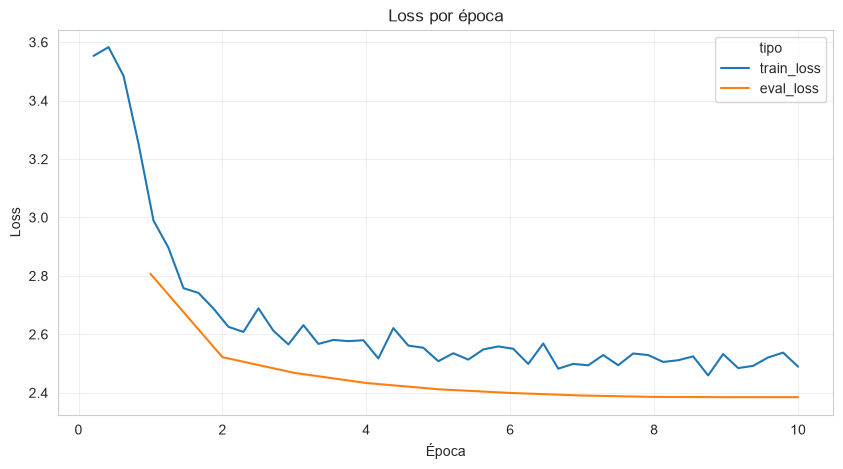

In [35]:
# Dicionário para armazenar perdas por época
loss_by_epoch = {}

# 1. Extrair perdas de treino
for log in logs:
    if 'loss' in log and 'epoch' in log:
        ep = log['epoch']
        loss_by_epoch.setdefault(ep, {})['train_loss'] = log['loss']

# 2. Extrair perdas de validação
for log in logs:
    if 'eval_loss' in log and 'epoch' in log:
        ep = log['epoch']
        loss_by_epoch.setdefault(ep, {})['eval_loss'] = log['eval_loss']

# 3. Converter para DataFrame
df = pd.DataFrame.from_dict(loss_by_epoch, orient='index').sort_index()
df.index.name = 'epoch'
df = df.reset_index()  # transforma índice 'epoch' em coluna

# Plotar
sns.set_style('whitegrid')
plt.figure(figsize=(10,5))
df_melt = df.melt(id_vars='epoch', var_name='tipo', value_name='loss')
sns.lineplot(data=df_melt, x='epoch', y='loss', hue='tipo')
plt.title('Loss por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.savefig('curvas_por_epoca.png', dpi=150, bbox_inches='tight')
plt.show()

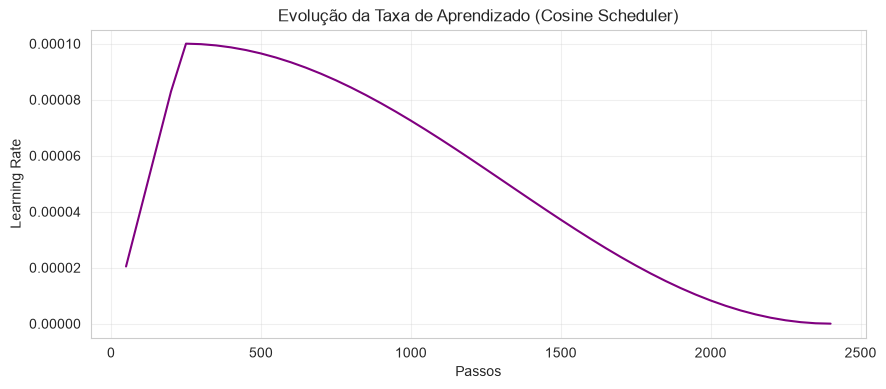

In [13]:
# Gráfico da evolução da LR
if lrs:
    plt.figure(figsize=(10,4))
    sns.lineplot(x=steps_lr, y=lrs, color='purple')
    plt.xlabel('Passos')
    plt.ylabel('Learning Rate')
    plt.title('Evolução da Taxa de Aprendizado (Cosine Scheduler)')
    plt.grid(True, alpha=0.3)
    plt.savefig('lr_evolution.png', dpi=150, bbox_inches='tight')
    plt.show()

## Inferência

Carrega o melhor modelo salvo e testa com perguntas fixas.

**Parâmetros de geração**:
- `do_sample=False` → modo guloso, respostas determinísticas e sem alucinações.
- `repetition_penalty=2.0` → penaliza repetições.
- `no_repeat_ngram_size=4` → impede repetição de 4‑gramas (elimina loops).
- `max_new_tokens=60` → respostas curtas e diretas.

Esta função é exatamente a que será usada no Streamlit.

In [7]:
def carregar_modelo():
    base = AutoModelForCausalLM.from_pretrained(BASE)
    modelo = PeftModel.from_pretrained(base, PASTA_SAIDA).to(device)
    modelo.eval()
    return modelo

In [8]:
import re

def responder(pergunta, modelo, contexto='', **kwargs):
    # 1. Mescla os parâmetros do YAML com os sobrescritos (kwargs)
    gen_params = {**GEN_CONFIG, **kwargs}
    
    # 2. Monta o prompt
    prefixo = f"### Contexto:\n{contexto}\n\n" if contexto.strip() else ''
    prompt = f"{prefixo}### Pergunta:\n{pergunta}\n\n### Resposta:\n"
    ids = tok(prompt, return_tensors='pt').to(device)
    
    # 3. Constrói os argumentos para o generate() dinamicamente
    generate_kwargs = {
        'max_new_tokens': gen_params.get('max_new_tokens', 60),
        'do_sample': gen_params.get('do_sample', False),
        'num_beams': gen_params.get('num_beams', 4),          # 🔥 BEAM SEARCH
        'repetition_penalty': gen_params.get('repetition_penalty', 2.0),
        'no_repeat_ngram_size': gen_params.get('no_repeat_ngram_size', 4),
        'temperature': gen_params.get('temperature', 0.7),    # usado só se do_sample=True
        'top_p': gen_params.get('top_p', 0.9),                # usado só se do_sample=True
        'pad_token_id': tok.eos_token_id,
        'eos_token_id': tok.eos_token_id
    }
    
    # 4. Geração
    with torch.no_grad():
        outputs = modelo.generate(**ids, **generate_kwargs)
    
    # 5. Decodifica e extrai a resposta
    resposta = tok.decode(outputs[0], skip_special_tokens=True)
    if "### Resposta:" in resposta:
        resposta = resposta.split("### Resposta:")[-1].strip()
    else:
        resposta = resposta.strip()
    
    # 6. 🔥 Pós‑processamento: corta na primeira frase
    match = re.search(r'^([^.!?]*[.!?])', resposta)
    if match:
        return match.group(1).strip()
    
    # Fallback seguro
    return resposta

In [9]:
modelo_final = carregar_modelo()
perguntas = [
    'Como posso reduzir o estresse no dia a dia?',
    'O que é hipertensão?',
    'Quais são os benefícios de uma boa noite de sono?',
    'Explique o que é vacinação.'
]
for p in perguntas:
    print('P:', p)
    print('R:', responder(p, modelo_final))
    print()

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: pierreguillou/gpt2-small-portuguese
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


P: Como posso reduzir o estresse no dia a dia?
R: O estresse no dia pode ser causado por uma série de fatores.

P: O que é hipertensão?
R: A hipertensão pode ser causada por uma série de fatores, incluindo o consumo excessivo de bebidas alcoólicas, a ingestão excessiva de alimentos ricos em gordura e a exposição à radiação ultravioleta.

P: Quais são os benefícios de uma boa noite de sono?
R: Os benefícios de uma ótima noite de sono podem ser divididos em três categorias principais.

P: Explique o que é vacinação.
R: A vacinação é uma medida de prevenção contra doenças infecciosas, como a varíola e a febre amarela.



In [10]:
# Antes (sem beam search) – vai parecer com as respostas antigas
print("SEM beam search:")
print(responder("O que é hipertensão?", modelo_final, num_beams=1))

print("\nCOM beam search (4):")
print(responder("O que é hipertensão?", modelo_final, num_beams=4))

SEM beam search:
A principal causa de problemas cardíacos está em excesso e falta da atenção.

COM beam search (4):
A hipertensão pode ser causada por uma série de fatores, incluindo o consumo excessivo de bebidas alcoólicas, a ingestão excessiva de alimentos ricos em gordura e a exposição à radiação ultravioleta.
